#### Reloading state from preprocess pipeline

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
BASE_DIR   = r"C:\Users\RAJA\Desktop\DA\Projects\FailSafe\backend\ml"
MODELS_DIR = os.path.join(BASE_DIR, "models")
DATA_DIR   = os.path.join(BASE_DIR, "data")

In [3]:
# Load saved artifacts from preprocess
scaler       = joblib.load(os.path.join(MODELS_DIR, "scaler.pkl"))
encoders     = joblib.load(os.path.join(MODELS_DIR, "encoders.pkl"))
metadata     = joblib.load(os.path.join(MODELS_DIR, "metadata.pkl"))
feature_cols = metadata["feature_cols"]

In [4]:
# Rebuild X, y from scratch using same pipeline
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(os.path.join(DATA_DIR, "student-por.csv"), sep=";")

# Risk labels
df["risk_binary"] = (df["G3"] < 10).astype(int)
df["risk_level"]  = pd.cut(df["G3"], bins=[-1, 9, 14, 20],
                            labels=[0, 1, 2]).astype(int)

# Cap absences
df["absences"] = df["absences"].clip(upper=df["absences"].quantile(0.95))

# Encode using saved encoders
df_model = df.copy()
for col, le in encoders.items():
    if col in df_model.columns:
        df_model[col] = le.transform(df_model[col].astype(str))

In [5]:
# Feature matrix
DROP_COLS = metadata["drop_cols"]
X = df_model.drop(columns=DROP_COLS, errors="ignore")
y = df["risk_binary"]

In [6]:
# Scale
SCALE_COLS = metadata["scale_cols"]
X_scaled        = X.copy()
X_scaled[SCALE_COLS] = scaler.transform(X[SCALE_COLS])

In [7]:
# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"State reloaded ✓")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Features: {list(X_train.columns)}")

State reloaded ✓
X_train: (519, 28) | X_test: (130, 28)
Features: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'goout', 'Dalc', 'Walc', 'absences', 'G1', 'G2']


### Model Training

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### Random Forest 

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

cv_rf = cross_validate(rf_model, X_train, y_train, cv=cv,
                        scoring=["accuracy", "f1", "roc_auc"])
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

#### XGBoost

In [11]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

cv_xgb = cross_validate(xgb_model, X_train, y_train, cv=cv,
                         scoring=["accuracy", "f1", "roc_auc"])
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### CV Summary

In [12]:
print("=" * 55)
print(f"{'Metric':<12} {'Random Forest':>18} {'XGBoost':>18}")
print("=" * 55)
for metric, key in [("Accuracy", "test_accuracy"),
                     ("F1 Score", "test_f1"),
                     ("ROC-AUC",  "test_roc_auc")]:
    rf_score  = f"{cv_rf[key].mean():.3f} ± {cv_rf[key].std():.3f}"
    xgb_score = f"{cv_xgb[key].mean():.3f} ± {cv_xgb[key].std():.3f}"
    print(f"{metric:<12} {rf_score:>18} {xgb_score:>18}")
print("=" * 55)
print("\nBoth models trained ✓")

Metric            Random Forest            XGBoost
Accuracy          0.935 ± 0.033      0.929 ± 0.040
F1 Score          0.813 ± 0.089      0.784 ± 0.110
ROC-AUC           0.972 ± 0.016      0.971 ± 0.020

Both models trained ✓


### Evaluating on test set

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)


Random Forest — Test Set
              precision    recall  f1-score   support

 Not At-Risk       0.97      0.86      0.91       110
     At-Risk       0.53      0.85      0.65        20

    accuracy                           0.86       130
   macro avg       0.75      0.86      0.78       130
weighted avg       0.90      0.86      0.87       130


XGBoost — Test Set
              precision    recall  f1-score   support

 Not At-Risk       0.96      0.92      0.94       110
     At-Risk       0.64      0.80      0.71        20

    accuracy                           0.90       130
   macro avg       0.80      0.86      0.83       130
weighted avg       0.91      0.90      0.90       130



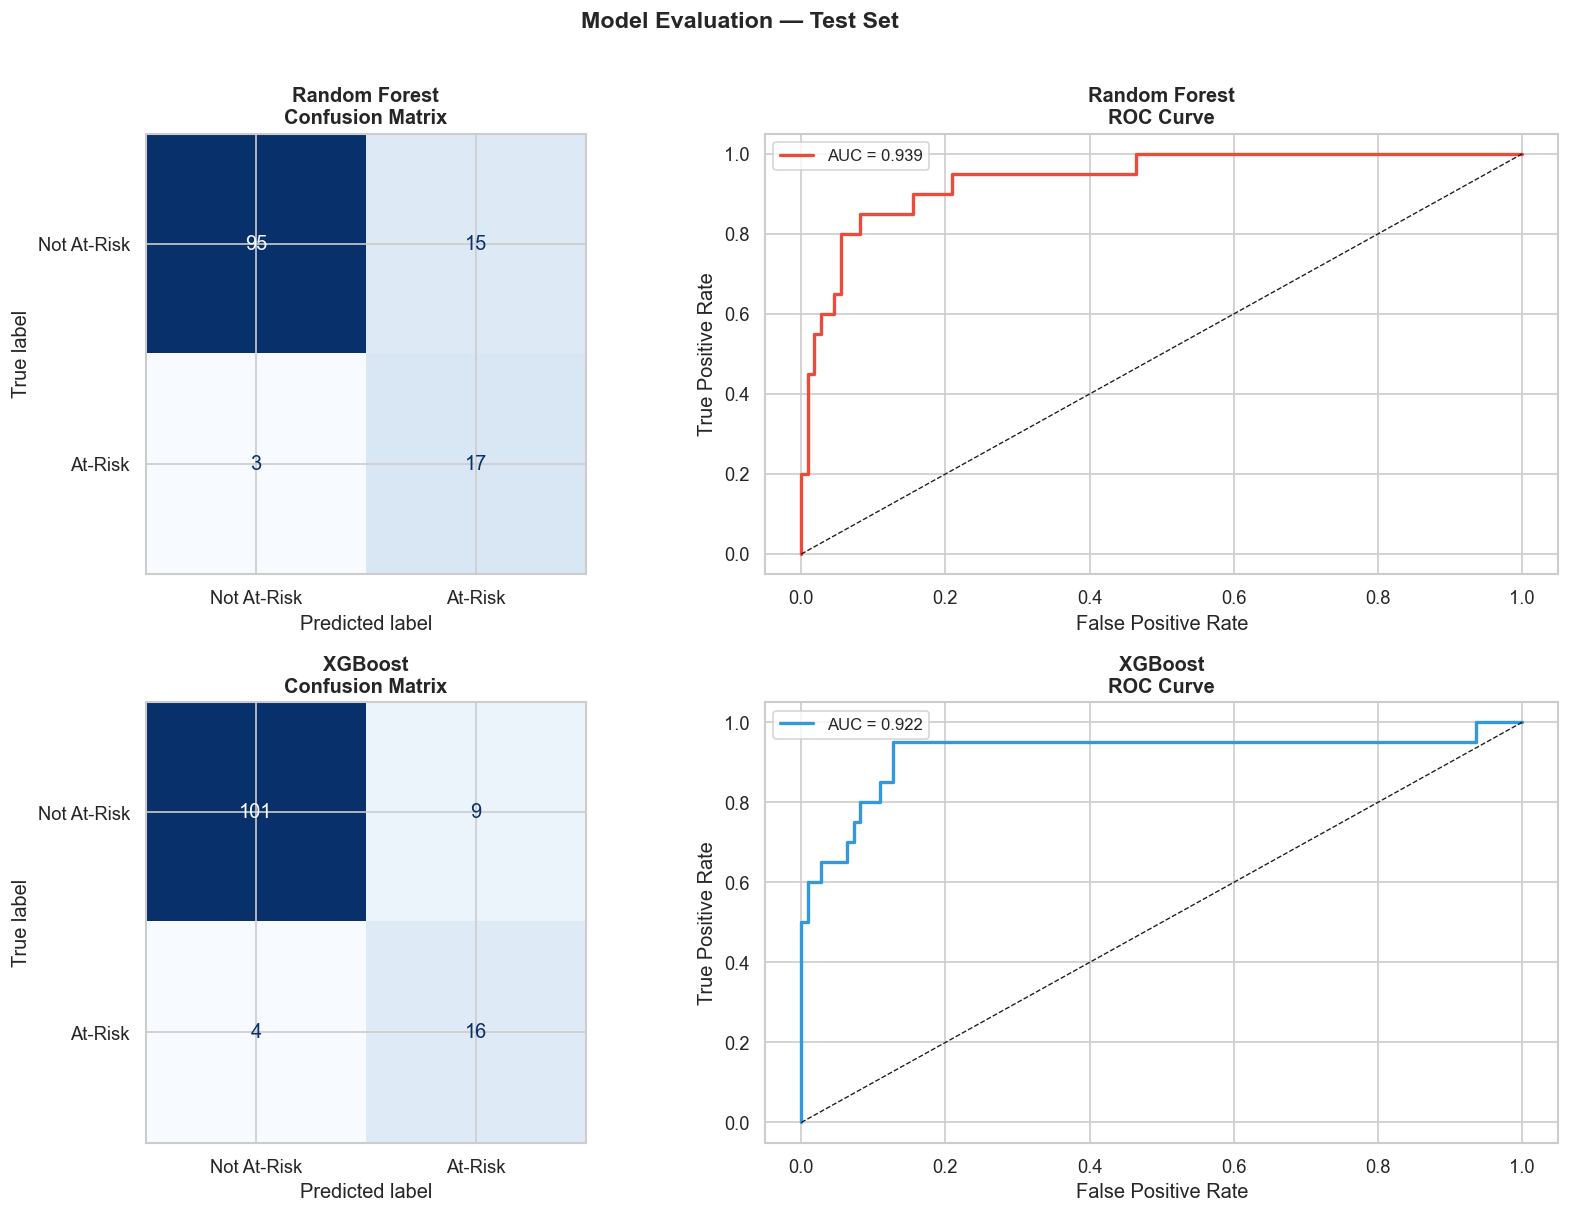

In [14]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ["#e74c3c", "#3498db"]

for idx, (name, model) in enumerate([("Random Forest", rf_model),
                                      ("XGBoost",       xgb_model)]):
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auc         = roc_auc_score(y_test, y_pred_prob)

    print(f"\n{'='*55}")
    print(f"{name} — Test Set")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=["Not At-Risk", "At-Risk"]))

    # Confusion matrix
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm,
               display_labels=["Not At-Risk", "At-Risk"])
    disp.plot(ax=axes[idx][0], colorbar=False, cmap="Blues")
    axes[idx][0].set_title(f"{name}\nConfusion Matrix",
                            fontweight="bold")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    axes[idx][1].plot(fpr, tpr, color=colors[idx],
                      linewidth=2, label=f"AUC = {auc:.3f}")
    axes[idx][1].plot([0,1], [0,1], "k--", linewidth=0.8)
    axes[idx][1].set_xlabel("False Positive Rate")
    axes[idx][1].set_ylabel("True Positive Rate")
    axes[idx][1].set_title(f"{name}\nROC Curve", fontweight="bold")
    axes[idx][1].legend(fontsize=10)

plt.suptitle("Model Evaluation — Test Set", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

#### Saving Models

In [15]:
joblib.dump(rf_model,  os.path.join(MODELS_DIR, "rf_model.pkl"))
joblib.dump(xgb_model, os.path.join(MODELS_DIR, "xgb_model.pkl"))

print("\nModels saved ✓")
print(f"\nFinal model selection: XGBoost (primary)")
print(f"  → Higher At-Risk F1    : XGBoost wins")
print(f"  → Fewer false positives: XGBoost wins")
print(f"  → Smaller model size   : 256KB vs 1.1MB")


Models saved ✓

Final model selection: XGBoost (primary)
  → Higher At-Risk F1    : XGBoost wins
  → Fewer false positives: XGBoost wins
  → Smaller model size   : 256KB vs 1.1MB
